In [2]:
# pip install numpy pandas scikit-learn xgboost psutil matplotlib seaborn openpyxl jupyter

# Evaluacion HPC y Cloud Computing para deteccion de ciberataques
## Notebook LOCAL — Escenarios S1 (sin optimizacion) y S3 (optimizado)
**Grupo 4 — Universidad del Pacifico**

Este notebook ejecuta la **mitad local** del diseno factorial 2x2 (infraestructura x optimizacion) sobre el dataset **UNSW-NB15**. El notebook gemelo (`HPC_CP_Grupo4_S2_S4_Azure.ipynb`) ejecuta S2 y S4 en la VM de Azure.

**Equidad de la comparacion:** la maquina local es mas potente que la VM (16 nucleos / 22 logicos vs 4 vCPU). Para que la comparacion mida el efecto de la *infraestructura* y no el de tener mas nucleos, este notebook se **limita a `N_CORES` nucleos logicos** (= los de la VM). El banner de la Seccion 3 documenta el hardware real y el limite aplicado.

**Convencion de outputs** (carpeta `outputs/`): por escenario `S1_…`, `S3_…`; exploratorio `EDA_…`; agregados del entorno `LOCAL_…`; consolidado final `ENTREGA_FINAL_…`.

**Orden de uso:** (1) corre este notebook completo en local; (2) corre el notebook Azure en la VM; (3) trae los `AZURE_*.csv` a `outputs/tables/`; (4) re-ejecuta la Seccion 13 (consolidacion final).

## 1. Parametros globales y limite de nucleos (equidad)

In [3]:
import os

# ---- Identidad de ESTE notebook ----
ENTORNO = "local"                 # Ejecuta S1 (sin opt) y S3 (optimizado) en LOCAL
ESCENARIOS = ["S1", "S3"]
PREFIX_ENV = "LOCAL"              # Prefijo de outputs a nivel de entorno

# ---- LIMITE DE NUCLEOS (equidad LOCAL vs AZURE) ----
# La VM Azure elegida (Standard_D4s_v3) tiene 4 vCPU. Para que la comparacion
# mida el efecto de la INFRAESTRUCTURA y no el de tener mas nucleos, limitamos
# este entorno local al mismo numero de nucleos logicos que la VM.
# IMPORTANTE: estas variables se setean ANTES de importar numpy/sklearn/xgboost
# para que las librerias BLAS (OpenBLAS/MKL) respeten el limite de hilos.
N_CORES = int(os.environ.get("N_CORES", "4"))
for _v in ["OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"]:
    os.environ[_v] = str(N_CORES)

# ---- Control del experimento ----
N_REPETICIONES = int(os.environ.get("N_REPETICIONES", "5"))   # 1 = prueba rapida
RANDOM_SEED_BASE = 42
TEST_SIZE = 0.2

# ---- Dataset (nombre MODIFICABLE; se asume 1ra fila = encabezados) ----
DATA_FILENAME = "UNSW-NB15_1.csv"
DATA_PATH = os.environ.get("DATA_PATH", DATA_FILENAME)
FEATURES_PATH = os.environ.get("FEATURES_PATH", "NUSWNB15_features.xlsx")  # opcional

# ---- Directorios de salida ----
OUTPUT_DIR = "outputs"
FIGURES_DIR = os.path.join(OUTPUT_DIR, "figures")
TABLES_DIR = os.path.join(OUTPUT_DIR, "tables")
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR, exist_ok=True)

print(f"Entorno         : {ENTORNO.upper()}  -> escenarios {ESCENARIOS}")
print(f"N_CORES (limite): {N_CORES}")
print(f"N_REPETICIONES  : {N_REPETICIONES}")
print(f"DATA_PATH       : {DATA_PATH}")
print(f"Outputs en      : {OUTPUT_DIR}/ (prefijos S1_, S3_, EDA_, LOCAL_)")

Entorno         : LOCAL  -> escenarios ['S1', 'S3']
N_CORES (limite): 4
N_REPETICIONES  : 5
DATA_PATH       : UNSW-NB15_1.csv
Outputs en      : outputs/ (prefijos S1_, S3_, EDA_, LOCAL_)


## 2. Importacion de librerias y modulos `.py`
El codigo reutilizable vive en `preprocessing.py` y `evaluation.py` (modularizacion solicitada por el profesor). Deben estar en la misma carpeta.

In [4]:
import sys, os, time, platform, socket
from datetime import datetime
import numpy as np
import pandas as pd
import psutil
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn, xgboost
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Importa los modulos .py (modularizacion solicitada por el profesor).
# Deben estar en la MISMA carpeta que este notebook.
try:
    from preprocessing import (preprocess_minimal, preprocess_optimized,
                               reduce_memory_usage, split_data, TARGET_COL)
    from evaluation import ResourceMonitor, build_models, train_evaluate_once
except ModuleNotFoundError as e:
    raise ModuleNotFoundError(
        "Faltan preprocessing.py y/o evaluation.py en la misma carpeta que "
        "este notebook. Copialos junto al .ipynb antes de ejecutar.") from e

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
sns.set_style("whitegrid")
plt.rcParams["figure.max_open_warning"] = 0
print("Imports OK | Python", sys.version.split()[0],
      "| sklearn", sklearn.__version__, "| xgboost", xgboost.__version__)

Imports OK | Python 3.13.9 | sklearn 1.7.2 | xgboost 3.2.0


## 3. Banner de especificaciones del sistema (pre-ejecucion)
Antes de correr nada, se imprimen y guardan las specs del entorno: SO, CPU, nucleos fisicos/logicos, nucleos usados, RAM y versiones de librerias.

In [5]:
def get_hardware_info():
    vm = psutil.virtual_memory()
    return {
        "entorno": ENTORNO,
        "fecha_ejecucion": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "hostname": socket.gethostname(),
        "sistema_operativo": platform.system() + " " + platform.release(),
        "arquitectura": platform.machine(),
        "python_version": sys.version.split()[0],
        "cpu_modelo": platform.processor() or "no disponible",
        "cpu_nucleos_fisicos": psutil.cpu_count(logical=False),
        "cpu_nucleos_logicos": psutil.cpu_count(logical=True),
        "n_cores_usados_experimento": N_CORES,
        "ram_total_gb": round(vm.total / (1024 ** 3), 2),
        "ram_disponible_gb": round(vm.available / (1024 ** 3), 2),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scikit_learn": sklearn.__version__,
        "xgboost": xgboost.__version__,
    }

hw = get_hardware_info()
print("=" * 64)
print(" ESPECIFICACIONES DEL SISTEMA QUE EJECUTA EL CODIGO ".center(64, "="))
print("=" * 64)
for k, v in hw.items():
    print(f"  {k:30s}: {v}")
print("=" * 64)
print(f"  NOTA: el experimento se limita a N_CORES={N_CORES} nucleos logicos")
print(f"        para una comparacion equitativa LOCAL vs AZURE.")
print("=" * 64)

hardware_df = pd.DataFrame([hw]).T.reset_index()
hardware_df.columns = ["caracteristica", "valor"]
hardware_df.to_csv(os.path.join(TABLES_DIR, f"{PREFIX_ENV}_tabla_hardware.csv"), index=False)
display(hardware_df)

====== ESPECIFICACIONES DEL SISTEMA QUE EJECUTA EL CODIGO ======
  entorno                       : local
  fecha_ejecucion               : 2026-06-19 21:34:03
  hostname                      : LPIRPW0GL759
  sistema_operativo             : Windows 11
  arquitectura                  : AMD64
  python_version                : 3.13.9
  cpu_modelo                    : Intel64 Family 6 Model 170 Stepping 4, GenuineIntel
  cpu_nucleos_fisicos           : 16
  cpu_nucleos_logicos           : 22
  n_cores_usados_experimento    : 4
  ram_total_gb                  : 31.32
  ram_disponible_gb             : 13.4
  numpy                         : 2.3.5
  pandas                        : 2.3.3
  scikit_learn                  : 1.7.2
  xgboost                       : 3.2.0
  NOTA: el experimento se limita a N_CORES=4 nucleos logicos
        para una comparacion equitativa LOCAL vs AZURE.


,caracteristica,valor
0,entorno,local
1,fecha_ejecucion,2026-06-19 21:34:03
2,hostname,LPIRPW0GL759
3,sistema_operativo,Windows 11
4,arquitectura,AMD64
5,python_version,3.13.9
6,cpu_modelo,"Intel64 Family 6 Model 170 Stepping 4, Genuine..."
7,cpu_nucleos_fisicos,16
8,cpu_nucleos_logicos,22
9,n_cores_usados_experimento,4


## 4. Carga del dataset UNSW-NB15
Se asume que el CSV tiene los **encabezados en la primera fila**. El nombre del archivo es configurable en `DATA_FILENAME` (Seccion 1).

In [7]:
def load_dataset(path):
    """Carga el CSV asumiendo que la PRIMERA FILA contiene los encabezados."""
    t0 = time.perf_counter()
    df = pd.read_csv(path, low_memory=False)
    return df, time.perf_counter() - t0

assert os.path.exists(DATA_PATH), (
    f"No se encontro el dataset en: {DATA_PATH}\n"
    f"Coloca '{DATA_FILENAME}' junto al notebook o define la variable de "
    f"entorno DATA_PATH.")

mon = ResourceMonitor(interval=0.1); mon.start()
df, load_time = load_dataset(DATA_PATH)
load_stats = mon.stop()

# Normalizacion defensiva del nombre de la columna objetivo
if "Label" not in df.columns:
    for cand in ["label", "LABEL"]:
        if cand in df.columns:
            df = df.rename(columns={cand: "Label"}); break
assert "Label" in df.columns, "No se encontro la columna objetivo 'Label'."

print(f"Dimensiones : {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Carga       : {load_time:.3f} s | RAM pico {load_stats['ram_peak_gb']:.2f} GB")
print(f"Memoria df  : {df.memory_usage(deep=True).sum()/(1024**2):.2f} MB")
df.head(3)

Dimensiones : 700,001 filas x 49 columnas
Carga       : 3.623 s | RAM pico 19.02 GB
Memoria df  : 496.20 MB


,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,dttl,sloss,dloss,service,Sload,Dload,Spkts,Dpkts,swin,dwin,stcpb,dtcpb,smeansz,dmeansz,trans_depth,res_bdy_len,Sjit,Djit,Stime,Ltime,Sintpkt,Dintpkt,tcprtt,synack,ackdat,is_sm_ips_ports,ct_state_ttl,ct_flw_http_mthd,is_ftp_login,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,Label
0,59.166.0.0,1390,149.171.126.6,53,udp,CON,0.0011,132,164,31,29,0,0,dns,500473.9375,621800.9375,2,2,0,0,0,0,66,82,0,0,0.0000,0.0000,1421927414,1421927414,0.0170,0.0130,0.0000,0.0000,0.0000,0,0,0,0,0,3,7,1,3,1,1,1,NaN,0
1,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.0361,528,304,31,29,0,0,-,87676.0859,50480.1719,4,4,0,0,0,0,132,76,0,0,9.8910,10.6827,1421927414,1421927414,7.0050,7.5643,0.0000,0.0000,0.0000,0,0,0,0,0,2,4,2,3,1,1,2,NaN,0
2,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.0011,146,178,31,29,0,0,dns,521894.5313,636282.3750,2,2,0,0,0,0,73,89,0,0,0.0000,0.0000,1421927414,1421927414,0.0170,0.0130,0.0000,0.0000,0.0000,0,0,0,0,0,12,8,1,2,2,1,1,NaN,0


## 5. Analisis exploratorio (EDA)
El EDA se realiza **solo en este notebook local** porque el dataset es identico en ambos entornos. Genera las figuras `EDA_…` para el paper.

,cantidad,porcentaje
Normal (0),677786,96.8300
Ataque (1),22215,3.1700


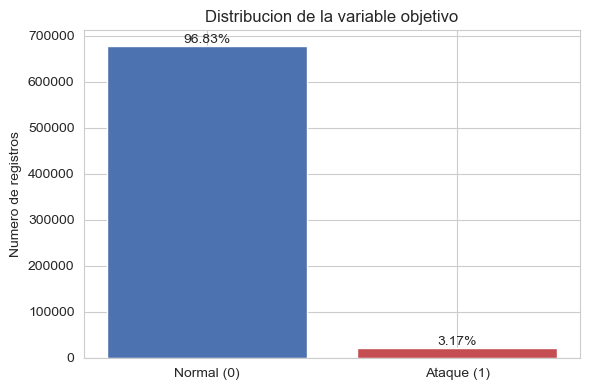

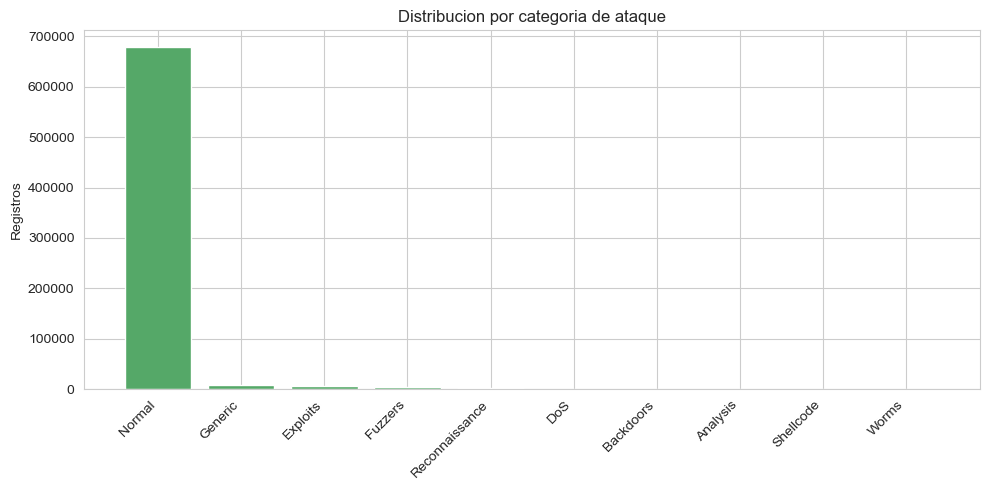

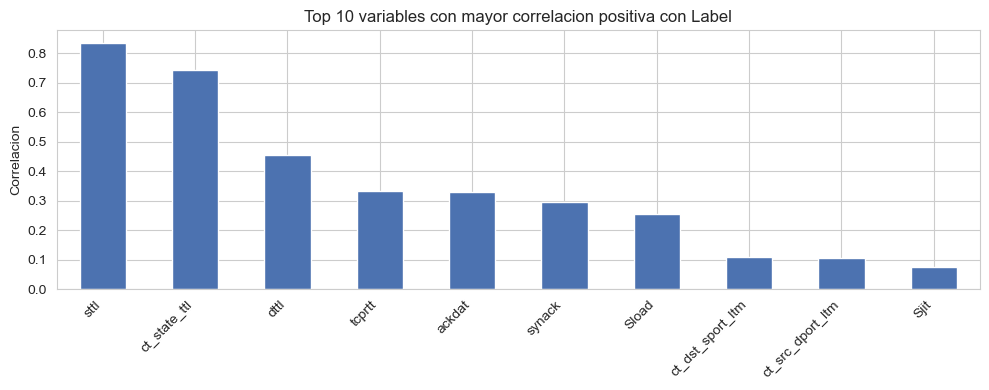

In [8]:
# Distribucion de la variable objetivo (Label)
label_counts = df["Label"].value_counts().sort_index()
label_pct = df["Label"].value_counts(normalize=True).sort_index() * 100
label_dist = pd.DataFrame({"cantidad": label_counts.values,
                           "porcentaje": label_pct.round(2).values},
                          index=["Normal (0)", "Ataque (1)"])
label_dist.to_csv(os.path.join(TABLES_DIR, "EDA_tabla_distribucion_label.csv"))
display(label_dist)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(label_dist.index, label_dist["cantidad"], color=["#4C72B0", "#C44E52"])
ax.set_title("Distribucion de la variable objetivo")
ax.set_ylabel("Numero de registros")
for bar, pct in zip(bars, label_dist["porcentaje"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{pct:.2f}%",
            ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "EDA_fig_distribucion_label.png"), dpi=300, bbox_inches="tight")
plt.show()

# Distribucion por categoria de ataque (si existe)
if "attack_cat" in df.columns:
    attack_dist = df["attack_cat"].fillna("Normal").value_counts()
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(attack_dist.index.astype(str), attack_dist.values, color="#55A868")
    ax.set_title("Distribucion por categoria de ataque"); ax.set_ylabel("Registros")
    plt.xticks(rotation=45, ha="right"); plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "EDA_fig_distribucion_attack_cat.png"), dpi=300, bbox_inches="tight")
    plt.show()

# Top correlaciones con Label
numeric_df = df.select_dtypes(include=[np.number]).copy()
corr = numeric_df.corr(numeric_only=True)["Label"].drop("Label", errors="ignore").sort_values(ascending=False)
top_corr = corr.head(10)
fig, ax = plt.subplots(figsize=(10, 4))
top_corr.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Top 10 variables con mayor correlacion positiva con Label"); ax.set_ylabel("Correlacion")
plt.xticks(rotation=45, ha="right"); plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "EDA_fig_correlacion_label.png"), dpi=300, bbox_inches="tight")
plt.show()

## 6. Preprocesamiento modular y reduccion de memoria
`preprocess_minimal` (S1) mantiene `srcip`/`dstip`; `preprocess_optimized` (S3) las elimina, convierte puertos a numerico y reduce memoria con downcasting.

In [9]:
print(">> Preprocesamiento SIN optimizacion (S1 / S2)...")
mem_before = df.memory_usage(deep=True).sum() / (1024 ** 2)
df_no_opt, _ = preprocess_minimal(df)
mem_no_opt = df_no_opt.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"   Memoria antes  : {mem_before:.2f} MB | sin opt: {mem_no_opt:.2f} MB | shape {df_no_opt.shape}")

print(">> Preprocesamiento OPTIMIZADO (S3 / S4)...")
df_opt, _ = preprocess_optimized(df)
mem_opt = df_opt.memory_usage(deep=True).sum() / (1024 ** 2)
red = (1 - mem_opt / mem_no_opt) * 100 if mem_no_opt > 0 else 0
print(f"   Memoria optim. : {mem_opt:.2f} MB | shape {df_opt.shape} | reduccion {red:.2f}%")

memory_table = pd.DataFrame({
    "pipeline": ["Sin optimizacion", "Optimizado"],
    "memoria_mb": [round(mem_no_opt, 2), round(mem_opt, 2)],
    "reduccion_vs_sin_opt_pct": [0.0, round(red, 2)],
})
memory_table.to_csv(os.path.join(TABLES_DIR, f"{PREFIX_ENV}_tabla_optimizacion_memoria.csv"), index=False)
display(memory_table)

>> Preprocesamiento SIN optimizacion (S1 / S2)...
   Memoria antes  : 496.20 MB | sin opt: 256.35 MB | shape (700001, 48)
>> Preprocesamiento OPTIMIZADO (S3 / S4)...
   Memoria optim. : 92.13 MB | shape (700001, 46) | reduccion 64.06%


,pipeline,memoria_mb,reduccion_vs_sin_opt_pct
0,Sin optimizacion,256.3500,0.0000
1,Optimizado,92.1300,64.0600


## 7. Funciones de ejecucion de escenarios
`run_scenario` corre `N_REPETICIONES` x 3 modelos (RF, XGBoost, MLP), midiendo tiempo/CPU/RAM por repeticion y guardando la matriz de confusion de la ultima. `export_scenario_outputs` exporta todo con prefijo `S#_`.

In [10]:
def run_scenario(df_processed, scenario_label, scenario_type, env, n_reps, n_cores):
    """Ejecuta N repeticiones x 3 modelos para un escenario.

    Devuelve (results_df con TODAS las repeticiones, dict de matrices de
    confusion de la ultima repeticion).
    """
    results = []
    confusion_matrices = {}
    for rep in range(n_reps):
        seed = RANDOM_SEED_BASE + rep
        print(f"  [{scenario_label}] Repeticion {rep+1}/{n_reps} (seed={seed})")
        X_train, X_test, y_train, y_test = split_data(df_processed, random_state=seed)
        # Escalado SOLO para el MLP (sensible a la escala)
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)
        models = build_models(scenario_type, seed, n_cores)
        for name, model in models.items():
            Xtr, Xte = (X_train_s, X_test_s) if name == "MLP" else (X_train, X_test)
            res, y_pred = train_evaluate_once(model, Xtr, Xte, y_train, y_test,
                                              name, scenario_label, rep + 1)
            res["env"] = env
            res["n_cores"] = n_cores
            results.append(res)
            print(f"    {name:13s} train={res['train_time_sec']:7.2f}s "
                  f"f1={res['f1_score']:.4f} cpu_peak={res['cpu_train_peak_pct']:5.1f}% "
                  f"conv_warn={res['convergence_warning']}")
            if rep == n_reps - 1:
                confusion_matrices[name] = confusion_matrix(y_test, y_pred)
    return pd.DataFrame(results), confusion_matrices


METRIC_COLS = ["train_time_sec", "inference_time_sec", "total_time_sec",
               "accuracy", "precision", "recall", "f1_score",
               "cpu_train_peak_pct", "cpu_train_avg_pct", "ram_train_peak_gb"]


def make_summary(results_df):
    """Resumen media +/- desviacion estandar por (escenario, modelo)."""
    s = results_df.groupby(["scenario", "model"])[METRIC_COLS].agg(["mean", "std"]).round(4)
    s.columns = ["_".join(c).strip() for c in s.columns.values]
    return s.reset_index()


def export_scenario_outputs(results_df, cms, skey):
    """Exporta detallado, resumen, confusion (tabla + PNG) con prefijo S#_."""
    results_df.to_csv(os.path.join(TABLES_DIR, f"{skey}_tabla_resultados_detallados.csv"), index=False)
    summ = make_summary(results_df)
    summ.to_csv(os.path.join(TABLES_DIR, f"{skey}_tabla_resultados_resumen.csv"), index=False)
    rows = []
    for model_name, cm in cms.items():
        tn, fp, fn, tp = cm.ravel()
        rows.append({"escenario": skey, "modelo": model_name,
                     "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
                     "tasa_FN_pct": round(fn / (fn + tp) * 100, 2) if (fn + tp) > 0 else 0})
        fig, ax = plt.subplots(figsize=(4.5, 4))
        ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Normal", "Ataque"]).plot(
            ax=ax, cmap="Blues", colorbar=False, values_format="d")
        ax.set_title(f"{model_name} - {skey}")
        plt.tight_layout()
        plt.savefig(os.path.join(FIGURES_DIR, f"{skey}_fig_confusion_{model_name.lower()}.png"),
                    dpi=300, bbox_inches="tight")
        plt.show(); plt.close(fig)
    pd.DataFrame(rows).to_csv(os.path.join(TABLES_DIR, f"{skey}_tabla_confusion.csv"), index=False)
    return summ

## 8. Ejecucion de escenarios locales
### 8.1 Escenario 1 — Local sin optimizacion

ESCENARIO 1: LOCAL SIN OPTIMIZACION
  [S1 - Local sin opt] Repeticion 1/5 (seed=42)
    RandomForest  train=  44.39s f1=0.9778 cpu_peak= 36.6% conv_warn=False
    XGBoost       train=  10.73s f1=0.9790 cpu_peak= 48.7% conv_warn=False
    MLP           train=  93.08s f1=0.9506 cpu_peak= 54.8% conv_warn=False
  [S1 - Local sin opt] Repeticion 2/5 (seed=43)
    RandomForest  train=  69.90s f1=0.9800 cpu_peak= 52.6% conv_warn=False
    XGBoost       train=  11.59s f1=0.9659 cpu_peak= 18.6% conv_warn=False
    MLP           train= 122.25s f1=0.9465 cpu_peak= 78.9% conv_warn=False
  [S1 - Local sin opt] Repeticion 3/5 (seed=44)
    RandomForest  train=  60.29s f1=0.9805 cpu_peak= 53.6% conv_warn=False
    XGBoost       train=  16.21s f1=0.9726 cpu_peak= 51.0% conv_warn=False
    MLP           train=  80.53s f1=0.9408 cpu_peak= 92.2% conv_warn=False
  [S1 - Local sin opt] Repeticion 4/5 (seed=45)
    RandomForest  train=  74.99s f1=0.9781 cpu_peak= 58.7% conv_warn=False
    XGBoost       trai

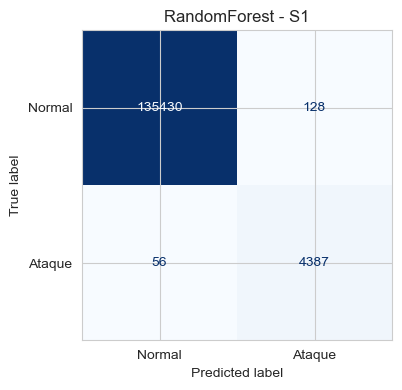

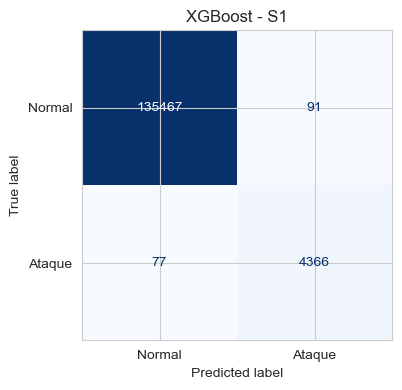

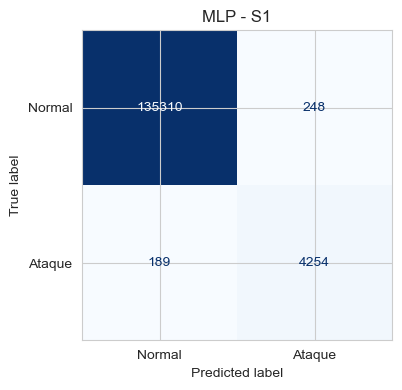

,scenario,model,train_time_sec_mean,train_time_sec_std,f1_score_mean
0,S1 - Local sin opt,MLP,78.8652,31.6396,0.9470
1,S1 - Local sin opt,RandomForest,58.8094,14.1494,0.9792
2,S1 - Local sin opt,XGBoost,10.9456,3.3512,0.9755


In [11]:
print("=" * 70); print("ESCENARIO 1: LOCAL SIN OPTIMIZACION"); print("=" * 70)
res_s1, cm_s1 = run_scenario(df_no_opt, "S1 - Local sin opt", "no_opt", "local", N_REPETICIONES, N_CORES)
sum_s1 = export_scenario_outputs(res_s1, cm_s1, "S1")
display(sum_s1[["scenario", "model", "train_time_sec_mean", "train_time_sec_std", "f1_score_mean"]])

### 8.2 Escenario 3 — Local optimizado
RF con `n_jobs=N_CORES` y `class_weight='balanced'`; XGBoost con `tree_method='hist'`; MLP con `max_iter=200`.

ESCENARIO 3: LOCAL OPTIMIZADO
  [S3 - Local opt] Repeticion 1/5 (seed=42)
    RandomForest  train=  19.94s f1=0.9739 cpu_peak= 45.8% conv_warn=False
    XGBoost       train=   3.69s f1=0.9759 cpu_peak= 36.4% conv_warn=False
    MLP           train=  49.40s f1=0.9427 cpu_peak= 41.1% conv_warn=False
  [S3 - Local opt] Repeticion 2/5 (seed=43)
    RandomForest  train=  18.64s f1=0.9743 cpu_peak= 39.0% conv_warn=False
    XGBoost       train=   3.72s f1=0.9775 cpu_peak= 41.7% conv_warn=False
    MLP           train=  55.16s f1=0.9404 cpu_peak= 81.7% conv_warn=False
  [S3 - Local opt] Repeticion 3/5 (seed=44)
    RandomForest  train=  25.30s f1=0.9749 cpu_peak= 76.8% conv_warn=False
    XGBoost       train=   4.04s f1=0.9774 cpu_peak= 37.8% conv_warn=False
    MLP           train=  53.87s f1=0.9424 cpu_peak= 31.3% conv_warn=False
  [S3 - Local opt] Repeticion 4/5 (seed=45)
    RandomForest  train=  32.63s f1=0.9737 cpu_peak= 60.5% conv_warn=False
    XGBoost       train=   5.86s f1=0.9764 c

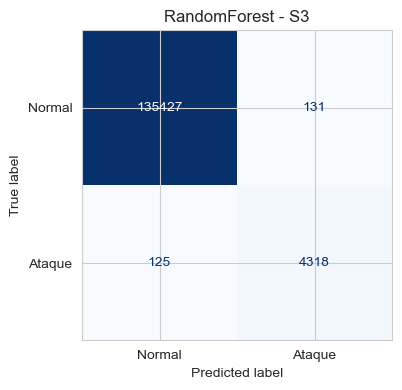

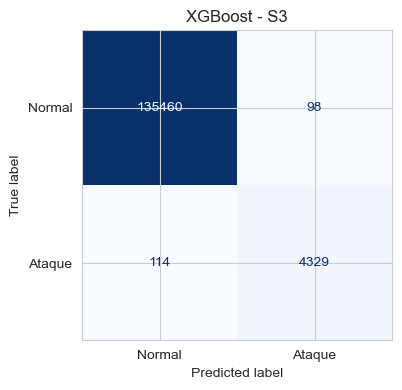

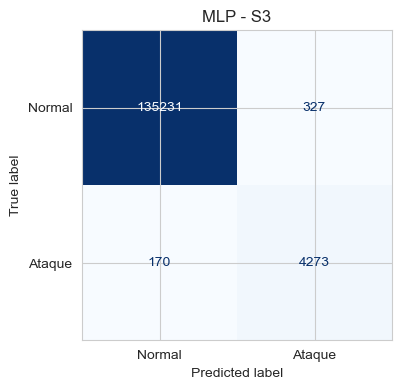

,scenario,model,train_time_sec_mean,train_time_sec_std,f1_score_mean
0,S3 - Local opt,MLP,64.4565,16.6721,0.9423
1,S3 - Local opt,RandomForest,24.9106,5.7773,0.9736
2,S3 - Local opt,XGBoost,4.4316,0.9231,0.9767


In [12]:
print("=" * 70); print("ESCENARIO 3: LOCAL OPTIMIZADO"); print("=" * 70)
res_s3, cm_s3 = run_scenario(df_opt, "S3 - Local opt", "opt", "local", N_REPETICIONES, N_CORES)
sum_s3 = export_scenario_outputs(res_s3, cm_s3, "S3")
display(sum_s3[["scenario", "model", "train_time_sec_mean", "train_time_sec_std", "f1_score_mean"]])

## 9. Resumen consolidado local (S1 + S3) y costo
El entorno local no tiene costo de VM (columna de costo = 0).

In [13]:
# Consolidado del entorno LOCAL (S1 + S3)
res_local = pd.concat([res_s1, res_s3], ignore_index=True)
res_local.to_csv(os.path.join(TABLES_DIR, "LOCAL_tabla_resultados_detallados.csv"), index=False)
summary_env = make_summary(res_local)
summary_env.to_csv(os.path.join(TABLES_DIR, "LOCAL_tabla_resultados_resumen_media_std.csv"), index=False)

# Costo: el entorno local no tiene costo de VM
OVERHEAD_SEC = 60.0
cost = res_local.groupby(["scenario", "env"])["total_time_sec"].sum().reset_index()
cost["overhead_sec"] = OVERHEAD_SEC
cost["tiempo_total_sec"] = cost["total_time_sec"] + cost["overhead_sec"]
cost["tiempo_total_hr"] = cost["tiempo_total_sec"] / 3600
cost["costo_usd_por_hora"] = 0.0
cost["costo_total_usd"] = 0.0
cost["vm_tipo"] = "Local (i7, 32GB)"
cost["region"] = "Lima (on-prem)"
cost.to_csv(os.path.join(TABLES_DIR, "LOCAL_tabla_costos.csv"), index=False)
display(summary_env[["scenario", "model", "train_time_sec_mean", "f1_score_mean"]])

,scenario,model,train_time_sec_mean,f1_score_mean
0,S1 - Local sin opt,MLP,78.8652,0.9470
1,S1 - Local sin opt,RandomForest,58.8094,0.9792
2,S1 - Local sin opt,XGBoost,10.9456,0.9755
3,S3 - Local opt,MLP,64.4565,0.9423
4,S3 - Local opt,RandomForest,24.9106,0.9736
5,S3 - Local opt,XGBoost,4.4316,0.9767


## 10. Figuras comparativas locales (S1 vs S3)

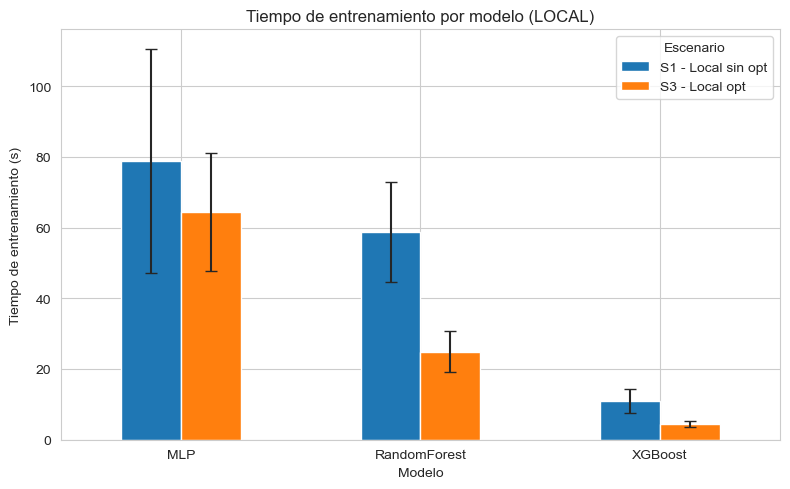

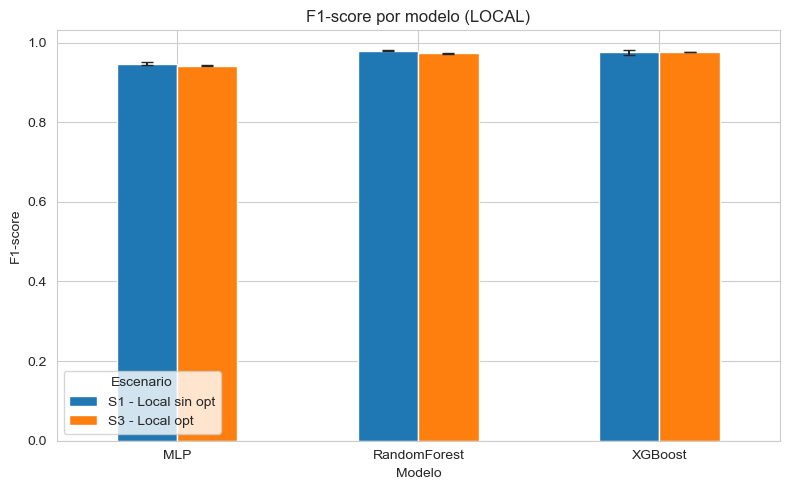

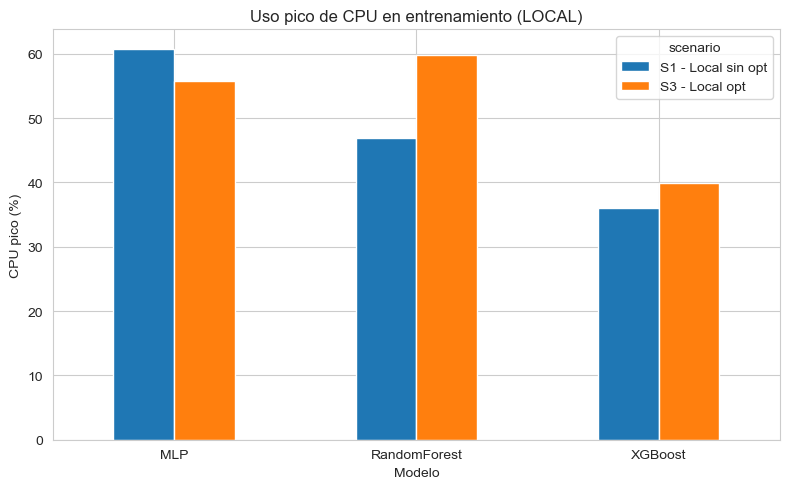

In [14]:
def barplot_with_errors(df_summary, value_col, error_col, ylabel, title, save_path):
    pivot_val = df_summary.pivot(index="model", columns="scenario", values=value_col)
    pivot_err = df_summary.pivot(index="model", columns="scenario", values=error_col)
    fig, ax = plt.subplots(figsize=(8, 5))
    pivot_val.plot(kind="bar", ax=ax, yerr=pivot_err, capsize=4)
    ax.set_title(title); ax.set_ylabel(ylabel); ax.set_xlabel("Modelo")
    plt.xticks(rotation=0); ax.legend(title="Escenario", loc="best")
    plt.tight_layout(); plt.savefig(save_path, dpi=300, bbox_inches="tight"); plt.show()

barplot_with_errors(summary_env, "train_time_sec_mean", "train_time_sec_std",
    "Tiempo de entrenamiento (s)",
    f"Tiempo de entrenamiento por modelo ({PREFIX_ENV})",
    os.path.join(FIGURES_DIR, f"{PREFIX_ENV}_fig_comparacion_tiempos.png"))

barplot_with_errors(summary_env, "f1_score_mean", "f1_score_std", "F1-score",
    f"F1-score por modelo ({PREFIX_ENV})",
    os.path.join(FIGURES_DIR, f"{PREFIX_ENV}_fig_comparacion_f1.png"))

pivot_cpu = summary_env.pivot(index="model", columns="scenario", values="cpu_train_peak_pct_mean")
fig, ax = plt.subplots(figsize=(8, 5))
pivot_cpu.plot(kind="bar", ax=ax)
ax.set_title(f"Uso pico de CPU en entrenamiento ({PREFIX_ENV})")
ax.set_ylabel("CPU pico (%)"); ax.set_xlabel("Modelo"); plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, f"{PREFIX_ENV}_fig_cpu_train.png"), dpi=300, bbox_inches="tight")
plt.show()

## 11. Libro Excel consolidado local
Insumo intermedio para el chat de LaTeX (`LOCAL_resultados.xlsx`).

In [15]:
# Libro Excel consolidado del entorno LOCAL (insumo para el chat de LaTeX)
xlsx_path = os.path.join(OUTPUT_DIR, "LOCAL_resultados.xlsx")
with pd.ExcelWriter(xlsx_path, engine="openpyxl") as xw:
    hardware_df.to_excel(xw, sheet_name="hardware", index=False)
    memory_table.to_excel(xw, sheet_name="memoria", index=False)
    res_local.to_excel(xw, sheet_name="detallado_S1_S3", index=False)
    summary_env.to_excel(xw, sheet_name="resumen_media_std", index=False)
    pd.read_csv(os.path.join(TABLES_DIR, "S1_tabla_confusion.csv")).to_excel(xw, sheet_name="confusion_S1", index=False)
    pd.read_csv(os.path.join(TABLES_DIR, "S3_tabla_confusion.csv")).to_excel(xw, sheet_name="confusion_S3", index=False)
    cost.to_excel(xw, sheet_name="costos_local", index=False)
print(f"Libro Excel generado: {xlsx_path}")

Libro Excel generado: outputs\LOCAL_resultados.xlsx


## 12. `requirements.txt` para replicar el entorno en la VM
Fija las versiones exactas de tu Anaconda local para reproducir el stack en Azure.

In [16]:
# requirements.txt con versiones fijadas (para replicar el entorno en la VM)
import openpyxl
reqs = {
    "numpy": np.__version__, "pandas": pd.__version__,
    "scikit-learn": sklearn.__version__, "xgboost": xgboost.__version__,
    "psutil": psutil.__version__, "matplotlib": matplotlib.__version__,
    "seaborn": sns.__version__, "openpyxl": openpyxl.__version__,
}
with open("requirements.txt", "w", encoding="utf-8") as f:
    for k, v in reqs.items():
        f.write(f"{k}=={v}\n")
print("requirements.txt generado con:")
for k, v in reqs.items():
    print(f"  {k}=={v}")

requirements.txt generado con:
  numpy==2.3.5
  pandas==2.3.3
  scikit-learn==1.7.2
  xgboost==3.2.0
  psutil==7.1.3
  matplotlib==3.10.6
  seaborn==0.13.2
  openpyxl==3.1.5


## 13. CONSOLIDACION FINAL Local + Azure
**Ejecuta esta seccion DESPUES** de correr el notebook Azure y traer los `AZURE_*.csv` a `outputs/tables/`. Genera las figuras cruzadas S1-S4, el dashboard, el Indice de Costo-Eficiencia (ICE) y el libro final `ENTREGA_FINAL_consolidado.xlsx`.

Outputs de Azure detectados: True


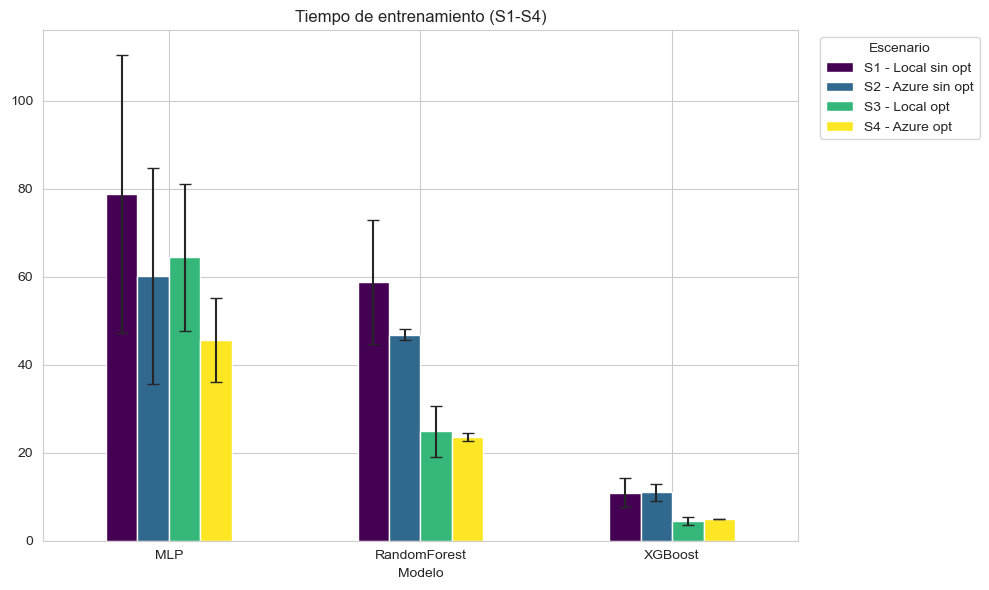

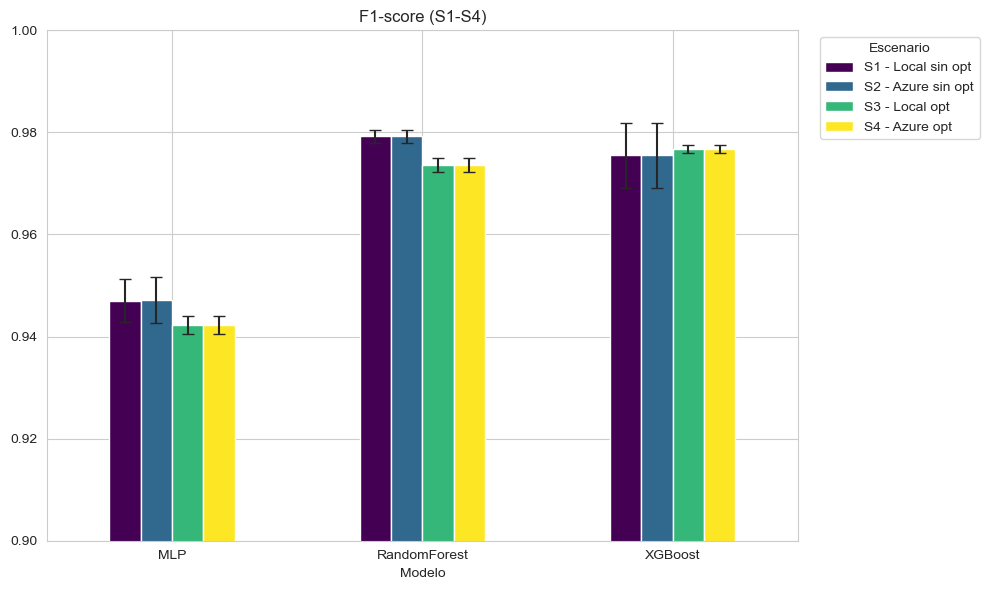

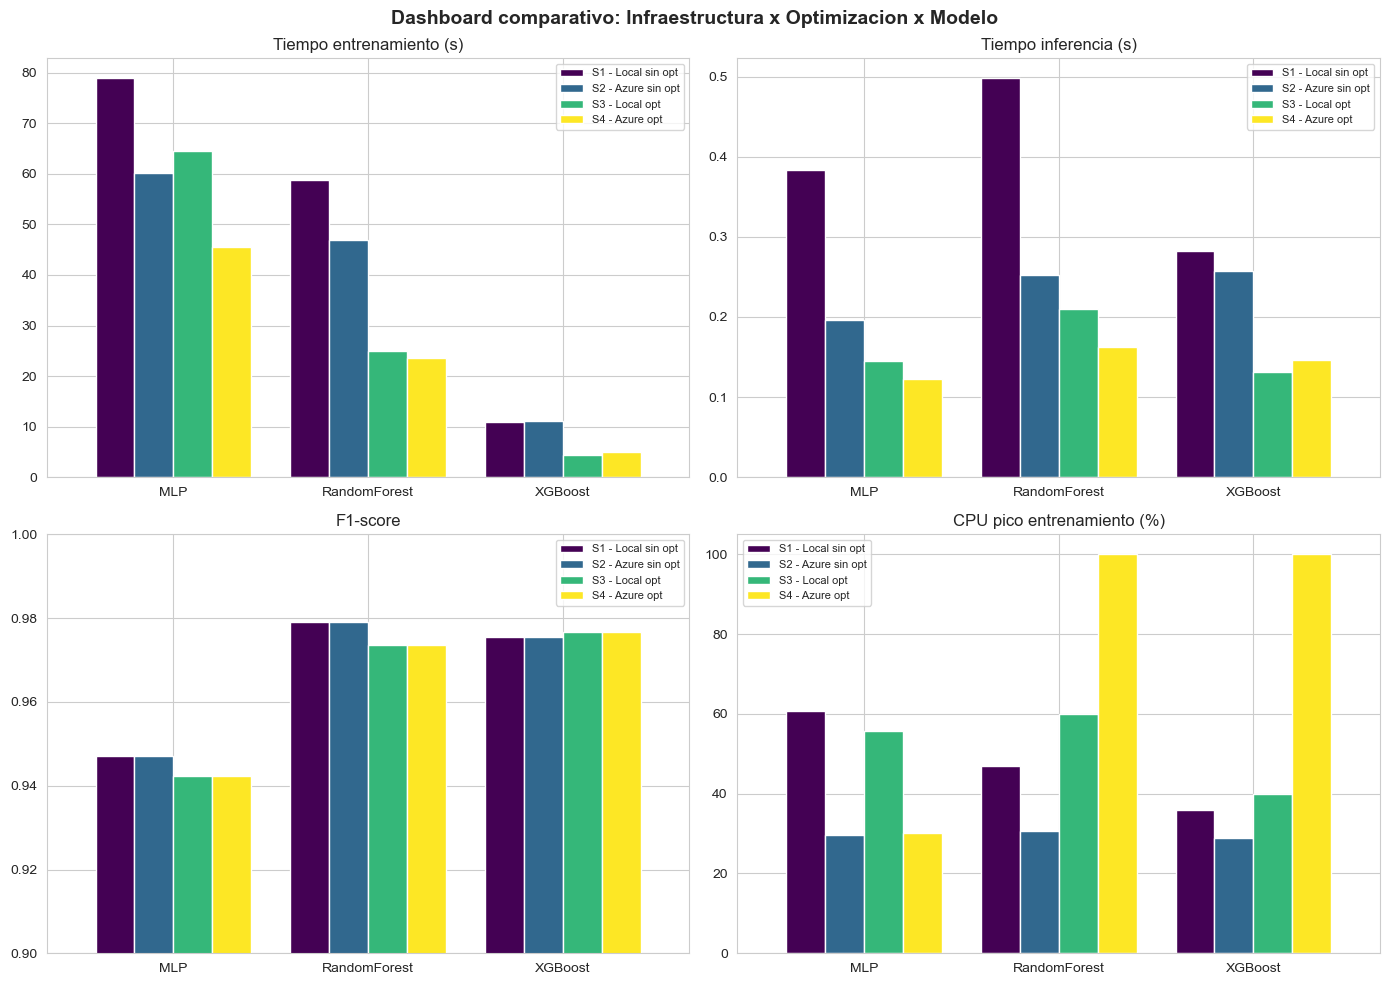

,entorno,modelo,t_base_seg,t_opt_seg,reduccion_pct,costo_usd_hora,ICE
0,local,MLP,78.8650,64.4570,18.2700,0.0000,NaN
1,local,RandomForest,58.8090,24.9110,57.6400,0.0000,NaN
2,local,XGBoost,10.9460,4.4320,59.5100,0.0000,NaN
3,azure,MLP,60.1240,45.6090,24.1400,0.2750,0.8779
4,azure,RandomForest,46.8200,23.6610,49.4600,0.2750,1.7987
5,azure,XGBoost,11.0590,4.9030,55.6700,0.2750,2.0243



>> Consolidacion completa. Libro final: outputs\ENTREGA_FINAL_consolidado.xlsx


In [18]:
# CONSOLIDACION FINAL: solo corre si ya trajiste los outputs de Azure
# (los CSV AZURE_*.csv deben estar en outputs/tables/).
azure_summary_path = os.path.join(TABLES_DIR, "AZURE_tabla_resultados_resumen_media_std.csv")
azure_detail_path = os.path.join(TABLES_DIR, "AZURE_tabla_resultados_detallados.csv")
azure_cost_path = os.path.join(TABLES_DIR, "AZURE_tabla_costos.csv")
azure_avail = os.path.exists(azure_summary_path)
print(f"Outputs de Azure detectados: {azure_avail}")

if not azure_avail:
    print("\n>> Aun no estan los resultados de Azure.")
    print("   1) Ejecuta el notebook Azure en la VM.")
    print("   2) Trae outputs/tables/AZURE_*.csv a esta carpeta (scp).")
    print("   3) Re-ejecuta esta seccion.")
else:
    summary_all = pd.concat([summary_env, pd.read_csv(azure_summary_path)], ignore_index=True)
    detail_all = pd.concat([res_local, pd.read_csv(azure_detail_path)], ignore_index=True)
    cost_all = pd.concat([cost, pd.read_csv(azure_cost_path)], ignore_index=True)
    summary_all.to_csv(os.path.join(TABLES_DIR, "ENTREGA_FINAL_tabla_resumen_media_std.csv"), index=False)
    detail_all.to_csv(os.path.join(TABLES_DIR, "ENTREGA_FINAL_tabla_detallado.csv"), index=False)
    cost_all.to_csv(os.path.join(TABLES_DIR, "ENTREGA_FINAL_tabla_costos.csv"), index=False)

    def order_cols(cols):
        return sorted(cols, key=lambda c: c.split(" ")[0])

    # Figuras cruzadas S1-S4
    for metric, err, title, fname, ylim in [
        ("train_time_sec_mean", "train_time_sec_std", "Tiempo de entrenamiento (S1-S4)",
         "ENTREGA_FINAL_fig_tiempos_s1_s4.png", None),
        ("f1_score_mean", "f1_score_std", "F1-score (S1-S4)",
         "ENTREGA_FINAL_fig_f1_s1_s4.png", (0.90, 1.00)),
    ]:
        pv = summary_all.pivot(index="model", columns="scenario", values=metric)
        pe = summary_all.pivot(index="model", columns="scenario", values=err)
        cols = order_cols(pv.columns); pv = pv[cols]; pe = pe[cols]
        fig, ax = plt.subplots(figsize=(10, 6))
        pv.plot(kind="bar", ax=ax, yerr=pe, capsize=4, colormap="viridis")
        ax.set_title(title); ax.set_xlabel("Modelo"); plt.xticks(rotation=0)
        if ylim: ax.set_ylim(*ylim)
        ax.legend(title="Escenario", bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.tight_layout(); plt.savefig(os.path.join(FIGURES_DIR, fname), dpi=300, bbox_inches="tight"); plt.show()

    # Dashboard 2x2 (INNOVACION)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Dashboard comparativo: Infraestructura x Optimizacion x Modelo",
                 fontsize=14, fontweight="bold")
    panels = [("train_time_sec_mean", "Tiempo entrenamiento (s)", (0, 0)),
              ("inference_time_sec_mean", "Tiempo inferencia (s)", (0, 1)),
              ("f1_score_mean", "F1-score", (1, 0)),
              ("cpu_train_peak_pct_mean", "CPU pico entrenamiento (%)", (1, 1))]
    for metric, label, pos in panels:
        ax = axes[pos[0], pos[1]]
        pv = summary_all.pivot(index="model", columns="scenario", values=metric)
        pv = pv[order_cols(pv.columns)]
        pv.plot(kind="bar", ax=ax, colormap="viridis", width=0.8)
        ax.set_title(label); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=0)
        ax.legend(fontsize=8)
        if metric == "f1_score_mean": ax.set_ylim(0.90, 1.00)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "ENTREGA_FINAL_fig_dashboard.png"), dpi=300, bbox_inches="tight")
    plt.show()

    # Indice de Costo-Eficiencia (ICE) = (1 - t_opt/t_base) / costo_usd_hora
    AZURE_VM_COST_PER_HOUR_USD = float(pd.read_csv(azure_cost_path)["costo_usd_por_hora"].max())
    def parse_env(label): return "azure" if "Azure" in label else "local"
    def parse_opt(label): return "opt" if "opt" in label and "sin" not in label else "no_opt"
    summary_all["_env"] = summary_all["scenario"].apply(parse_env)
    summary_all["_opt"] = summary_all["scenario"].apply(parse_opt)
    ice_rows = []
    for env in summary_all["_env"].unique():
        for model in summary_all["model"].unique():
            sub = summary_all[(summary_all["_env"] == env) & (summary_all["model"] == model)]
            b = sub[sub["_opt"] == "no_opt"]; o = sub[sub["_opt"] == "opt"]
            if len(b) == 0 or len(o) == 0: continue
            t_base = b["train_time_sec_mean"].values[0]; t_opt = o["train_time_sec_mean"].values[0]
            red = 1 - (t_opt / t_base) if t_base > 0 else 0
            costo = AZURE_VM_COST_PER_HOUR_USD if env == "azure" else 0.0
            ice = round(red / costo, 4) if costo > 0 else None
            ice_rows.append({"entorno": env, "modelo": model,
                             "t_base_seg": round(t_base, 3), "t_opt_seg": round(t_opt, 3),
                             "reduccion_pct": round(red * 100, 2),
                             "costo_usd_hora": costo, "ICE": ice})
    ice_df = pd.DataFrame(ice_rows)
    ice_df.to_csv(os.path.join(TABLES_DIR, "ENTREGA_FINAL_tabla_indice_costo_eficiencia.csv"), index=False)
    display(ice_df)

    # Libro Excel FINAL consolidado (insumo principal del chat de LaTeX)
    xlsx_final = os.path.join(OUTPUT_DIR, "ENTREGA_FINAL_consolidado.xlsx")
    with pd.ExcelWriter(xlsx_final, engine="openpyxl") as xw:
        summary_all.drop(columns=["_env", "_opt"]).to_excel(xw, sheet_name="resumen_media_std", index=False)
        detail_all.to_excel(xw, sheet_name="detallado_S1_S4", index=False)
        cost_all.to_excel(xw, sheet_name="costos", index=False)
        ice_df.to_excel(xw, sheet_name="indice_costo_eficiencia", index=False)
        for sk in ["S1", "S2", "S3", "S4"]:
            p = os.path.join(TABLES_DIR, f"{sk}_tabla_confusion.csv")
            if os.path.exists(p):
                pd.read_csv(p).to_excel(xw, sheet_name=f"confusion_{sk}", index=False)
    print(f"\n>> Consolidacion completa. Libro final: {xlsx_final}")

## 14. Cierre
Outputs en `outputs/tables/` (CSV) y `outputs/figures/` (PNG). El insumo principal para el paper es `ENTREGA_FINAL_consolidado.xlsx` (tras la consolidacion).